# Final Results Summary

This notebook summarizes the main experiment results.

It does not train models. It only reads CSV files from:

```text
outputs/metrics/
```

The goal is to create clean tables and figures for the README.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

def rel_path(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()

print("Setup complete.")
print("Metrics folder exists:", METRICS_DIR.exists())

Setup complete.
Metrics folder exists: True


## 2. Helper Functions

The notebooks may save slightly different CSV formats, so these helper functions make the summary more robust.

In [2]:
def read_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    print("Missing:", rel_path(path))
    return None


def pick_metric_row(df, split=None):
    if df is None or len(df) == 0:
        return None
    if split is not None and "split" in df.columns:
        sub = df[df["split"].astype(str).str.lower() == split.lower()]
        if len(sub) > 0:
            return sub.iloc[0].to_dict()
    return df.iloc[0].to_dict()


def get_value(row, names, default=np.nan):
    if row is None:
        return default
    for name in names:
        if name in row:
            return row[name]
    return default


def clean_model_name(name):
    name = str(name)
    replacements = {
        "Majority Class": "Majority Class",
        "Logistic Regression": "Logistic Regression",
        "Random Forest": "Random Forest",
        "RNN": "RNN",
        "LSTM": "LSTM",
        "GRU": "GRU",
        "Weighted GRU": "Weighted GRU",
    }
    return replacements.get(name, name)

## 3. Load Baseline Results

These are produced by:

```text
01_baseline_models.ipynb
```

In [3]:
baseline_path = METRICS_DIR / "baseline_summary.csv"
baseline_df = read_csv_if_exists(baseline_path)

if baseline_df is not None:
    baseline_df

## 4. Load Sequence Model Results

These are produced by:

```text
02_train_rnn.ipynb
03_train_lstm.ipynb
04_train_weighted_gru_final.ipynb
```

In [4]:
rnn_df = read_csv_if_exists(METRICS_DIR / "rnn_summary.csv")
lstm_df = read_csv_if_exists(METRICS_DIR / "lstm_summary.csv")
weighted_gru_df = read_csv_if_exists(METRICS_DIR / "gru_weighted_validation_vs_test.csv")

rows = []

if baseline_df is not None:
    for _, row in baseline_df.iterrows():
        rows.append({
            "model": clean_model_name(row.get("model", "")),
            "split": "validation",
            "accuracy": row.get("accuracy", np.nan),
            "macro_f1": row.get("macro_f1", np.nan),
            "weighted_f1": row.get("weighted_f1", np.nan),
            "down_f1": np.nan,
            "flat_f1": np.nan,
            "up_f1": np.nan,
        })

for model_name, df in [("RNN", rnn_df), ("LSTM", lstm_df)]:
    row = pick_metric_row(df, split="validation")
    if row is not None:
        rows.append({
            "model": model_name,
            "split": "validation",
            "accuracy": get_value(row, ["accuracy", "val_acc"]),
            "macro_f1": get_value(row, ["macro_f1", "val_macro_f1"]),
            "weighted_f1": get_value(row, ["weighted_f1", "val_weighted_f1"]),
            "down_f1": get_value(row, ["down_f1"]),
            "flat_f1": get_value(row, ["flat_f1"]),
            "up_f1": get_value(row, ["up_f1"]),
        })

row = pick_metric_row(weighted_gru_df, split="validation")
if row is not None:
    rows.append({
        "model": "Weighted GRU",
        "split": "validation",
        "accuracy": get_value(row, ["accuracy", "val_acc"]),
        "macro_f1": get_value(row, ["macro_f1", "val_macro_f1"]),
        "weighted_f1": get_value(row, ["weighted_f1", "val_weighted_f1"]),
        "down_f1": get_value(row, ["down_f1"]),
        "flat_f1": get_value(row, ["flat_f1"]),
        "up_f1": get_value(row, ["up_f1"]),
    })

model_comparison_df = pd.DataFrame(rows)
model_comparison_df = model_comparison_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

model_comparison_path = METRICS_DIR / "final_model_comparison_validation.csv"
model_comparison_df.to_csv(model_comparison_path, index=False)

print("Saved:", rel_path(model_comparison_path))
model_comparison_df

Saved: outputs/metrics/final_model_comparison_validation.csv


,model,split,accuracy,macro_f1,weighted_f1,down_f1,flat_f1,up_f1
0,Weighted GRU,validation,0.403672,0.393510,0.405835,0.369676,0.349338,0.461515
1,Logistic Regression,validation,0.434333,0.322640,0.367895,NaN,NaN,NaN
2,LSTM,validation,0.439169,0.315079,0.357146,0.122656,0.233312,0.589268
3,RNN,validation,0.445403,0.295099,0.342000,0.077389,0.205907,0.602001
4,Random Forest,validation,0.444958,0.293883,0.344021,NaN,NaN,NaN
5,Majority Class,validation,0.446325,0.205728,0.275465,NaN,NaN,NaN


## 5. Plot Validation Macro-F1

Macro-F1 is the main metric because the classes are imbalanced.

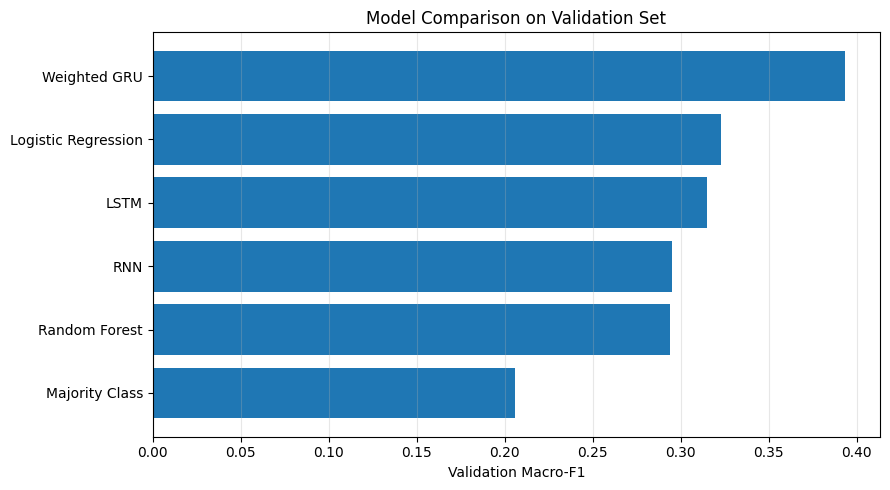

Saved: outputs/figures/final_validation_macro_f1_comparison.png


In [5]:
if len(model_comparison_df) > 0:
    plot_df = model_comparison_df.sort_values("macro_f1", ascending=True)

    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["model"], plot_df["macro_f1"])
    plt.xlabel("Validation Macro-F1")
    plt.title("Model Comparison on Validation Set")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    fig_path = FIGURES_DIR / "final_validation_macro_f1_comparison.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", rel_path(fig_path))

## 6. Final Model: Validation vs Test

This table checks how the final model generalizes to the out-of-sample test period.

In [6]:
final_model_df = weighted_gru_df.copy() if weighted_gru_df is not None else pd.DataFrame()

if len(final_model_df) > 0:
    keep_cols = [
        "split",
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "down_f1",
        "flat_f1",
        "up_f1",
    ]
    available_cols = [c for c in keep_cols if c in final_model_df.columns]
    final_model_clean = final_model_df[available_cols].copy()

    final_model_path = METRICS_DIR / "final_weighted_gru_validation_vs_test.csv"
    final_model_clean.to_csv(final_model_path, index=False)

    print("Saved:", rel_path(final_model_path))
    final_model_clean
else:
    print("Missing final weighted GRU results.")

Saved: outputs/metrics/final_weighted_gru_validation_vs_test.csv


## 7. Plot Final Model Validation vs Test

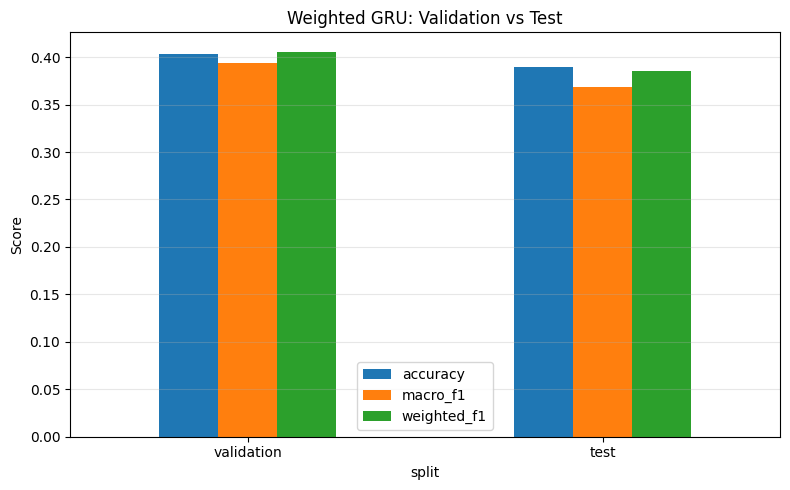

Saved: outputs/figures/final_weighted_gru_validation_vs_test.png


In [7]:
if len(final_model_df) > 0 and "split" in final_model_df.columns:
    needed = ["accuracy", "macro_f1", "weighted_f1"]
    plot_cols = [c for c in needed if c in final_model_df.columns]

    plot_data = final_model_df.set_index("split")[plot_cols]

    ax = plot_data.plot(kind="bar", figsize=(8, 5))
    ax.set_ylabel("Score")
    ax.set_title("Weighted GRU: Validation vs Test")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()

    fig_path = FIGURES_DIR / "final_weighted_gru_validation_vs_test.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", rel_path(fig_path))

## 8. Per-Class F1 for Final Model

This helps show which class is the hardest. In this project, the flat class is usually the most difficult.

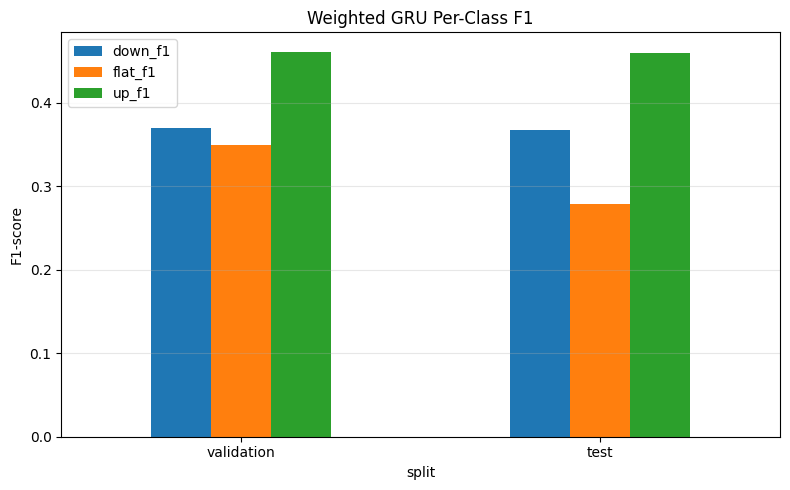

Saved: outputs/figures/final_weighted_gru_per_class_f1.png


In [8]:
if len(final_model_df) > 0 and "split" in final_model_df.columns:
    class_cols = ["down_f1", "flat_f1", "up_f1"]
    class_cols = [c for c in class_cols if c in final_model_df.columns]

    if len(class_cols) > 0:
        class_plot_df = final_model_df.set_index("split")[class_cols]

        ax = class_plot_df.plot(kind="bar", figsize=(8, 5))
        ax.set_ylabel("F1-score")
        ax.set_title("Weighted GRU Per-Class F1")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=0)
        plt.tight_layout()

        fig_path = FIGURES_DIR / "final_weighted_gru_per_class_f1.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()

        print("Saved:", rel_path(fig_path))

        class_plot_df

## 9. Market Feature Ablation

This compares stock-only features with stock + SPY market features.

In [9]:
market_ablation_path = METRICS_DIR / "gru_weighted_market_features_comparison_with_stock_only.csv"
market_ablation_df = read_csv_if_exists(market_ablation_path)

if market_ablation_df is not None:
    market_ablation_clean = market_ablation_df.copy()

    ablation_out = METRICS_DIR / "final_market_feature_ablation.csv"
    market_ablation_clean.to_csv(ablation_out, index=False)

    print("Saved:", rel_path(ablation_out))
    market_ablation_clean

Missing: outputs/metrics/gru_weighted_market_features_comparison_with_stock_only.csv


## 10. Plot Market Feature Ablation

In [10]:
if market_ablation_df is not None and len(market_ablation_df) > 0:
    if "split" in market_ablation_df.columns and "macro_f1" in market_ablation_df.columns:
        plot_df = market_ablation_df.copy()

        if "feature_set" not in plot_df.columns:
            plot_df["feature_set"] = plot_df.get("experiment", "model")

        pivot = plot_df.pivot_table(
            index="feature_set",
            columns="split",
            values="macro_f1",
            aggfunc="first",
        )

        ax = pivot.plot(kind="bar", figsize=(9, 5))
        ax.set_ylabel("Macro-F1")
        ax.set_title("Market Feature Ablation")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()

        fig_path = FIGURES_DIR / "final_market_feature_ablation.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()

        print("Saved:", rel_path(fig_path))
        pivot

## 11. Main Takeaways

These short notes can be reused in the README.

In [11]:
notes = [
    "Weighted GRU is the main model because it gives better macro-F1 than the unweighted sequence model and traditional baselines.",
    "Class weighting helps reduce the bias toward the majority up class.",
    "Test performance is lower than validation performance, which is expected for a strict chronological split.",
    "Adding simple SPY market features did not improve test macro-F1 in this experiment.",
]

for i, note in enumerate(notes, 1):
    print(f"{i}. {note}")

1. Weighted GRU is the main model because it gives better macro-F1 than the unweighted sequence model and traditional baselines.
2. Class weighting helps reduce the bias toward the majority up class.
3. Test performance is lower than validation performance, which is expected for a strict chronological split.
4. Adding simple SPY market features did not improve test macro-F1 in this experiment.


## 12. Save README Tables

This exports a few markdown tables that can be copied into the README.

In [12]:
readme_tables_dir = PROJECT_ROOT / "outputs" / "metrics"
readme_tables_dir.mkdir(parents=True, exist_ok=True)

if len(model_comparison_df) > 0:
    table_path = readme_tables_dir / "readme_model_comparison.md"
    table_path.write_text(model_comparison_df.to_markdown(index=False), encoding="utf-8")
    print("Saved:", rel_path(table_path))

if len(final_model_df) > 0:
    table_path = readme_tables_dir / "readme_final_model_validation_vs_test.md"
    final_model_clean.to_markdown(index=False)
    table_path.write_text(final_model_clean.to_markdown(index=False), encoding="utf-8")
    print("Saved:", rel_path(table_path))

if market_ablation_df is not None:
    table_path = readme_tables_dir / "readme_market_feature_ablation.md"
    table_path.write_text(market_ablation_df.to_markdown(index=False), encoding="utf-8")
    print("Saved:", rel_path(table_path))

Saved: outputs/metrics/readme_model_comparison.md
Saved: outputs/metrics/readme_final_model_validation_vs_test.md
